# Optimisation de portefeuille avec la CVaR

Dans ce projet, nous allons reconstruire pas à pas une optimisation de portefeuille basée sur la **CVaR** (*Conditional Value at Risk*), en nous inspirant de l'article de Thomas T. Bjerring.

L'idée générale est la suivante :

- nous sélectionnons plusieurs ETF représentant différentes classes d'actifs ;
- nous récupérons leurs prix historiques ;
- nous transformons ces prix en **rendements mensuels** ;
- puis nous construisons un portefeuille optimal en utilisant la **CVaR** comme mesure du risque.

## Pourquoi utiliser la CVaR ?

En finance, le risque n'est pas seulement la volatilité. Ce qui inquiète souvent le plus un investisseur, ce sont les **fortes pertes**.  
La CVaR mesure justement la **perte moyenne dans les pires scénarios**.

Autrement dit :

- la **VaR** donne un seuil de perte ;
- la **CVaR** regarde ce qu'il se passe **au-delà de ce seuil**, dans la queue de distribution.

La CVaR est donc particulièrement intéressante pour étudier le **risque extrême** d'un portefeuille.

## Univers d'investissement retenu

Nous allons utiliser les 5 ETF suivants :

- $SPY$ : actions américaines large cap
- $IJS$ : actions américaines small cap
- $EFA$ : actions internationales développées
- $EEM$ : actions émergentes
- $AGG$ : obligations agrégées

Cet univers est volontairement simple, mais suffisamment riche pour faire apparaître des effets de diversification.

## Objectif de cette première étape

Dans cette première partie, nous allons :

1. importer les bibliothèques nécessaires ;
2. télécharger les prix historiques ;
3. convertir ces prix en rendements mensuels ;
4. visualiser rapidement les données obtenues.

Nous travaillerons ensuite sur la modélisation mathématique de la CVaR et sur l'optimisation du portefeuille.

In [2]:
!pip install pulp

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.4 MB 3.1 MB/s eta 0:00:06
   --- ------------------------------------ 1.6/16.4 MB 4.9 MB/s eta 0:00:04
   -------- ------------------------------- 3.4/16.4 MB 6.6 MB/s eta 0:00:02
   ---------- ----------------------------- 4.5/16.4 MB 6.0 MB/s eta 0:00:02
   -------------- ------------------------- 6.0/16.4 MB 6.4 MB/s eta 0:00:02
   ------------------- -------------------- 7.9/16.4 MB 6.8 MB/s eta 0:00:02
   -------------------- ------------------- 8.4/16.4 MB 6.0 MB/s eta 0:00:02
   ------------------------- -------------- 10.5/16.4 MB 7.0 MB/s eta 0:00:01
   ------------------------------- -------- 12.8/16.4 MB 7.1 MB/s eta 0:00:01
   ----------------------------------- ---- 14.4/16.4 MB 7.2 MB/s eta 0:00:01
   -------------------------------------- - 15.7/16.4 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 6.9 MB/s  0:00:02



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# 1. Importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import pulp

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.4f}".format)

# 2. Paramètres du projet

start_date = "2010-01-01"
end_date = "2018-12-31"

tickers = ["SPY", "IJS", "EFA", "EEM", "AGG"]

In [4]:
# 3. Téléchargement des prix ajustés

prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)["Adj Close"]

print("Aperçu des prix ajustés :")
display(prices.head())

Aperçu des prix ajustés :


Ticker,AGG,EEM,EFA,IJS,SPY
Date,,,,,
2010-01-04,65.6292,30.3515,35.1284,23.3290,84.7964
2010-01-05,65.9278,30.5718,35.1594,23.1378,85.0209
2010-01-06,65.8897,30.6358,35.3080,23.1573,85.0807
2010-01-07,65.8134,30.4581,35.1718,23.3720,85.4398
2010-01-08,65.8515,30.6997,35.4504,23.4852,85.7242


In [5]:
# 4. Conversion en rendements mensuels

monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna()

print("Aperçu des rendements mensuels :")
display(monthly_returns.head())

Aperçu des rendements mensuels :


Ticker,AGG,EEM,EFA,IJS,SPY
Date,,,,,
2010-02-28,0.0020,0.0178,0.0027,0.0476,0.0312
2010-03-31,-0.0001,0.0811,0.0639,0.0780,0.0609
2010-04-30,0.0097,-0.0017,-0.0280,0.0663,0.0155
2010-05-31,0.0108,-0.0939,-0.1119,-0.0854,-0.0795
2010-06-30,0.0177,-0.0140,-0.0206,-0.0828,-0.0517


In [6]:
# 5. Informations générales

print("Dimensions des prix journaliers :", prices.shape)
print("Dimensions des prix mensuels :", monthly_prices.shape)
print("Dimensions des rendements mensuels :", monthly_returns.shape)

display(monthly_returns.describe().T)

Dimensions des prix journaliers : (2263, 5)
Dimensions des prix mensuels : (108, 5)
Dimensions des rendements mensuels : (107, 5)


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AGG,107.0000,0.0025,0.0083,-0.0257,-0.0025,0.0020,0.0086,0.0205
EEM,107.0000,0.0033,0.0528,-0.1789,-0.0294,-0.0004,0.0345,0.1627
EFA,107.0000,0.0045,0.0432,-0.1119,-0.0221,0.0053,0.0322,0.1161
IJS,107.0000,0.0103,0.0489,-0.1284,-0.0187,0.0130,0.0406,0.1534
SPY,107.0000,0.0102,0.0358,-0.0960,-0.0089,0.0128,0.0314,0.1091


## Première lecture des données

Nous avons maintenant transformé les prix en **rendements mensuels**.

Mathématiquement, pour un actif donné, le rendement mensuel s’écrit :

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

où :

- $P_t$ est le prix de fin du mois $t$ ;
- $P_{t-1}$ est le prix de fin du mois précédent ;
- $r_t$ est le rendement sur le mois.

Ces rendements mensuels vont jouer un rôle central dans la suite du projet, car ils représenteront nos **scénarios historiques** de marché.

Autrement dit, chaque mois observé dans le passé pourra être interprété comme une situation possible servant à mesurer le risque du portefeuille.

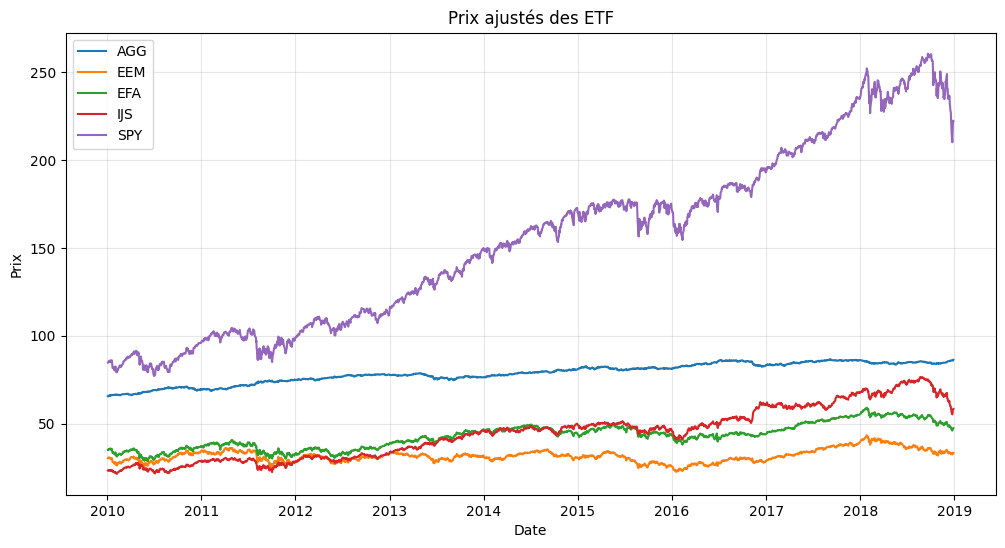

In [7]:
# 6. Graphique des prix ajustés

plt.figure(figsize=(12, 6))

for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.title("Prix ajustés des ETF")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

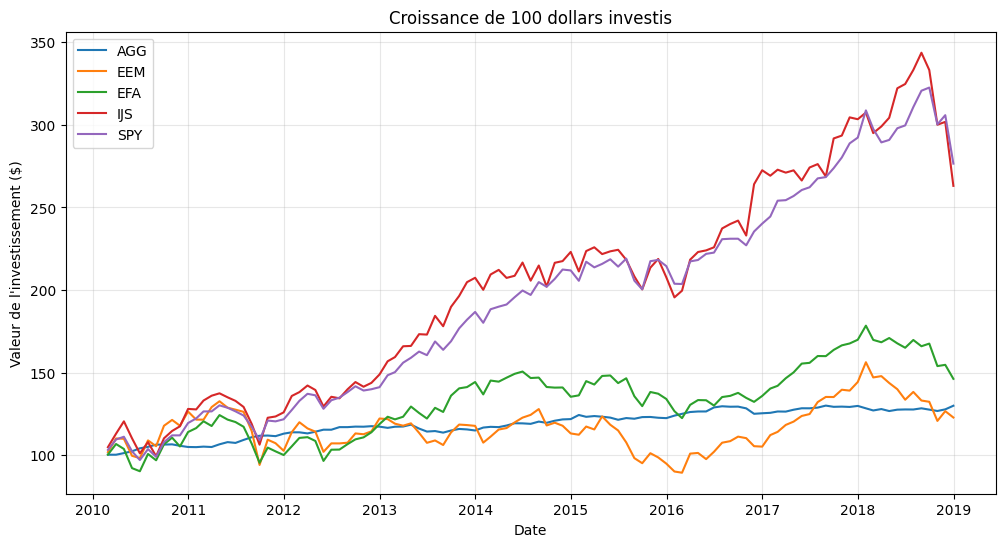

In [8]:
# 7. Croissance de 100 dollars investis

growth_100 = (1 + monthly_returns).cumprod() * 100

plt.figure(figsize=(12, 6))

for col in growth_100.columns:
    plt.plot(growth_100.index, growth_100[col], label=col)

plt.title("Croissance de 100 dollars investis")
plt.xlabel("Date")
plt.ylabel("Valeur de l'investissement ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Interprétation visuelle

Le premier graphique montre les **prix ajustés** des ETF au cours du temps.

Le second graphique est souvent plus parlant : il représente l’évolution de **100 dollars investis** au départ sur chaque actif.

La formule utilisée est :

$$
V_t = 100 \times \prod_{k=1}^{t} (1 + r_k)
$$

où :

- $V_t$ est la valeur cumulée de l’investissement à la date $t$ ;
- $r_k$ est le rendement du mois $k$.

Cette représentation permet de comparer plus facilement les performances relatives des actifs, puisqu’ils partent tous de la même base de 100 dollars.

# Comprendre la VaR et la CVaR

Avant d’optimiser un portefeuille, il faut définir précisément ce que l’on appelle le **risque**.

Dans l’approche classique de Markowitz, le risque est souvent mesuré par la **variance** ou l’**écart-type** des rendements.  
Cependant, cette vision ne distingue pas assez les fluctuations normales des **pertes extrêmes**.

Dans ce projet, nous allons utiliser une autre mesure : la **CVaR**.

## 1. La Value at Risk (VaR)

La **VaR** à un niveau de confiance $\alpha$ donne un seuil de perte.

Par exemple, une VaR à 95% signifie qu’en théorie, dans 95% des cas, la perte ne dépassera pas un certain niveau.

Autrement dit, la VaR répond à la question :

> quelle est la perte maximale attendue dans des conditions normales, pour un niveau de confiance donné ?

Mathématiquement, si l’on note $L$ la perte du portefeuille, la VaR au niveau $\alpha$ peut être vue comme un quantile :

$$
VaR_{\alpha}(L)
$$

C’est donc un seuil critique.

## 2. La Conditional Value at Risk (CVaR)

La **CVaR** va plus loin.

Au lieu de regarder seulement le seuil, elle mesure la **moyenne des pertes qui dépassent la VaR**.

Autrement dit, elle répond à la question :

> quand les choses se passent vraiment mal, quelle est la perte moyenne ?

On peut l’interpréter comme une mesure du risque de queue, c’est-à-dire du risque dans les pires scénarios.

## 3. Pourquoi la CVaR est intéressante ?

La CVaR est particulièrement utile car :

- elle prend en compte les pertes extrêmes ;
- elle est plus informative que la VaR seule ;
- elle se prête bien à l’optimisation mathématique, notamment en programmation linéaire.

C’est pour cette raison que nous allons construire ici une frontière efficiente **rendement - CVaR**, au lieu d’une frontière classique **rendement - variance**.

## Rendement et perte d’un portefeuille

Supposons que notre portefeuille soit composé de poids :

$$
w_1, w_2, \dots, w_n
$$

avec la contrainte classique :

$$
\sum_{i=1}^{n} w_i = 1
$$

Si $r_{i,t}$ désigne le rendement de l’actif $i$ au scénario (ou mois) $t$, alors le rendement du portefeuille au scénario $t$ est :

$$
R_{p,t} = \sum_{i=1}^{n} w_i r_{i,t}
$$

Dans une logique de risque, on s’intéresse souvent à la **perte**, donc à l’opposé du rendement :

$$
L_t = -R_{p,t}
$$

Ainsi :

- si le portefeuille réalise un bon rendement, la perte est faible ou négative ;
- si le portefeuille subit une forte baisse, la perte devient grande.

C’est cette distribution des pertes historiques que nous utiliserons pour calculer la VaR puis la CVaR.

In [9]:
# 8. Rendements moyens et matrice de scénarios

mu = monthly_returns.mean()
scenarios = monthly_returns.copy()

print("Rendements mensuels moyens :")
display(mu.to_frame(name="Rendement moyen mensuel"))

print("Dimensions de la matrice des scénarios :", scenarios.shape)

Rendements mensuels moyens :


,Rendement moyen mensuel
Ticker,
AGG,0.0025
EEM,0.0033
EFA,0.0045
IJS,0.0103
SPY,0.0102


Dimensions de la matrice des scénarios : (107, 5)


## Interprétation des objets utilisés

Nous avons maintenant deux objets essentiels :

### 1. Le vecteur des rendements moyens

Le vecteur :

$$
\mu = (\mu_1, \mu_2, \dots, \mu_n)
$$

contient le rendement moyen mensuel de chaque actif.

Il servira à calculer le rendement espéré du portefeuille :

$$
\mathbb{E}[R_p] = \sum_{i=1}^{n} w_i \mu_i
$$

### 2. La matrice des scénarios

La matrice des scénarios contient les rendements observés pour chaque actif et pour chaque mois.

Chaque ligne correspond donc à un **scénario historique**.

C’est une idée très importante : dans ce projet, nous n’allons pas supposer une loi théorique compliquée.  
Nous allons utiliser directement les données historiques comme base empirique pour mesurer le risque.

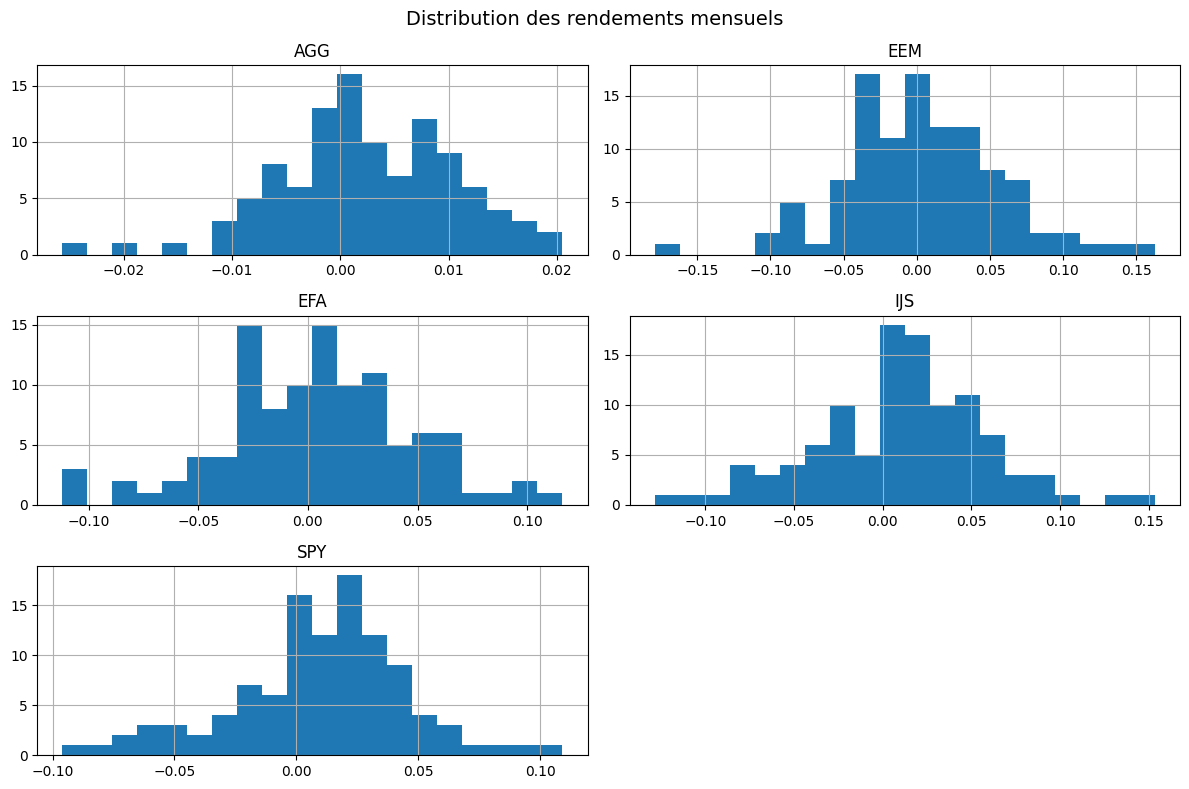

In [10]:
# 9. Histogrammes des rendements mensuels

monthly_returns.hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribution des rendements mensuels", fontsize=14)
plt.tight_layout()
plt.show()

## Pourquoi regarder la distribution des rendements ?

Ce graphique permet de mieux comprendre la dispersion des rendements de chaque actif.

On peut déjà observer plusieurs éléments :

- certains actifs ont des rendements plus concentrés ;
- d’autres présentent des distributions plus étalées ;
- les actifs actions ont généralement une dispersion plus forte que l’actif obligataire.

Cette lecture est importante, car la CVaR dépend précisément du comportement de la distribution dans les zones défavorables.

C:\Users\JulienRUIZ\AppData\Local\Temp\ipykernel_21452\1413968636.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([monthly_returns[col] for col in monthly_returns.columns], labels=monthly_returns.columns)


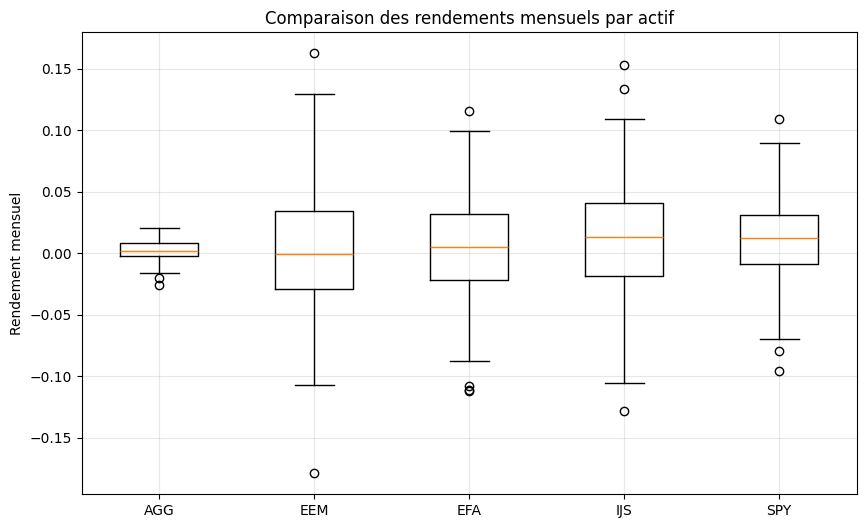

In [11]:
# 10. Boxplot des rendements mensuels

plt.figure(figsize=(10, 6))
plt.boxplot([monthly_returns[col] for col in monthly_returns.columns], labels=monthly_returns.columns)
plt.title("Comparaison des rendements mensuels par actif")
plt.ylabel("Rendement mensuel")
plt.grid(alpha=0.3)
plt.show()

## Lecture du boxplot

Le boxplot permet de comparer rapidement les profils de risque des actifs :

- la position centrale donne une idée du rendement médian ;
- la hauteur de la boîte reflète la dispersion centrale ;
- les extrémités indiquent des scénarios plus extrêmes.

On voit en général que :

- $AGG$ est plus stable ;
- les ETF actions comme $SPY$ ou $IJS$ présentent une plus grande variabilité ;
- certains actifs émergents ou internationaux peuvent avoir des épisodes plus défavorables.

Cette observation visuelle prépare bien la logique de la CVaR, qui se concentre justement sur les pires cas.

# Formulation de l’optimisation mean-CVaR

Nous voulons maintenant construire un portefeuille optimal à partir des rendements historiques.

## 1. Variables du portefeuille

On note :

$$
w_1, w_2, \dots, w_n
$$

les poids des actifs dans le portefeuille, avec la contrainte :

$$
\sum_{i=1}^{n} w_i = 1
$$

et dans notre cas :

$$
w_i \geq 0
$$

car nous imposons une contrainte **long only** : on n’autorise pas les ventes à découvert.

## 2. Rendement du portefeuille dans chaque scénario

Pour chaque scénario historique $t$, le rendement du portefeuille est :

$$
R_{p,t} = \sum_{i=1}^{n} w_i r_{i,t}
$$

où $r_{i,t}$ est le rendement de l’actif $i$ au scénario $t$.

La perte associée à ce scénario est alors :

$$
L_t = -R_{p,t}
$$

## 3. Idée de la linéarisation

Pour rendre la CVaR exploitable par un solveur linéaire, on introduit :

- une variable $VaR$ qui joue le rôle de seuil ;
- des variables auxiliaires $z_t \geq 0$ qui représentent les dépassements au-delà de ce seuil.

On impose alors, pour chaque scénario $t$ :

$$
z_t \geq L_t - VaR
$$

et

$$
z_t \geq 0
$$

Ainsi, si la perte d’un scénario dépasse la VaR, la variable $z_t$ capture cet excès.  
Sinon, elle reste égale à zéro.

## 4. Expression de la CVaR

Si l’on a $T$ scénarios historiques et un niveau de confiance $\alpha$, alors la CVaR empirique s’écrit :

$$
CVaR_{\alpha} = VaR + \frac{1}{(1-\alpha)T} \sum_{t=1}^{T} z_t
$$

Cette expression est linéaire en les variables de décision, ce qui est précisément ce qui rend l’optimisation possible avec `pulp`.

## 5. Objectif du problème

Dans un premier temps, nous allons fixer un **rendement cible minimal** et chercher le portefeuille qui **minimise la CVaR** sous cette contrainte.

Nous aurons donc :

- une contrainte sur le rendement espéré ;
- une contrainte de somme des poids ;
- des contraintes de positivité ;
- et une fonction objectif égale à la CVaR.

In [12]:
# 11. Fonction d'optimisation mean-CVaR

def optimize_portfolio_cvar(mu, scenarios, target_return, alpha=0.95):
    asset_names = list(mu.index)
    n_assets = len(asset_names)
    n_scenarios = scenarios.shape[0]

    model = pulp.LpProblem("Mean_CVaR_Optimization", pulp.LpMinimize)

    # Variables de décision
    weights = pulp.LpVariable.dicts("w", asset_names, lowBound=0)
    var = pulp.LpVariable("VaR")
    z = pulp.LpVariable.dicts("z", range(n_scenarios), lowBound=0)

    # Fonction objectif : minimiser la CVaR
    cvar = var + (1 / ((1 - alpha) * n_scenarios)) * pulp.lpSum(z[t] for t in range(n_scenarios))
    model += cvar

    # Contrainte : somme des poids = 1
    model += pulp.lpSum(weights[i] for i in asset_names) == 1

    # Contrainte : rendement espéré >= rendement cible
    model += pulp.lpSum(weights[i] * mu[i] for i in asset_names) >= target_return

    # Contraintes de dépassement pour chaque scénario
    for t in range(n_scenarios):
        portfolio_return_t = pulp.lpSum(weights[i] * scenarios.iloc[t][i] for i in asset_names)
        portfolio_loss_t = -portfolio_return_t
        model += z[t] >= portfolio_loss_t - var

    # Résolution
    model.solve(pulp.PULP_CBC_CMD(msg=0))

    # Récupération des résultats
    optimal_weights = pd.Series({i: weights[i].varValue for i in asset_names})
    var_value = var.varValue
    cvar_value = pulp.value(cvar)
    expected_return = float((optimal_weights * mu).sum())

    results = {
        "weights": optimal_weights,
        "expected_return": expected_return,
        "VaR": var_value,
        "CVaR": cvar_value,
        "status": pulp.LpStatus[model.status]
    }

    return results

## Lecture de la fonction d’optimisation

Cette fonction prend en entrée :

- le vecteur des rendements moyens `mu` ;
- la matrice des scénarios historiques `scenarios` ;
- un rendement cible `target_return` ;
- un niveau de confiance `alpha`.

Elle renvoie ensuite :

- les poids optimaux du portefeuille ;
- le rendement espéré du portefeuille ;
- la VaR estimée ;
- la CVaR minimale obtenue.

### Interprétation économique

Le solveur cherche ici le portefeuille le moins risqué au sens de la **CVaR**, tout en garantissant un rendement moyen au moins égal à un niveau fixé.

Cela signifie que l’on ne cherche pas encore le portefeuille "le plus rentable", mais plutôt le portefeuille :

- suffisamment rentable ;
- et le plus robuste possible face aux scénarios extrêmes.

In [13]:
# 12. Premier test avec un rendement cible simple

target_return = 0.005

result_test = optimize_portfolio_cvar(
    mu=mu,
    scenarios=scenarios,
    target_return=target_return,
    alpha=0.95
)

print("Statut du solveur :", result_test["status"])
print("Rendement espéré du portefeuille :", round(result_test["expected_return"], 6))
print("VaR estimée :", round(result_test["VaR"], 6))
print("CVaR estimée :", round(result_test["CVaR"], 6))

print("\nPoids optimaux :")
display(result_test["weights"].to_frame(name="Poids optimal"))

Statut du solveur : Optimal
Rendement espéré du portefeuille : 0.005
VaR estimée : 0.017519
CVaR estimée : 0.021016

Poids optimaux :


,Poids optimal
AGG,0.6729
EEM,0.0000
EFA,0.0000
IJS,0.0000
SPY,0.3271


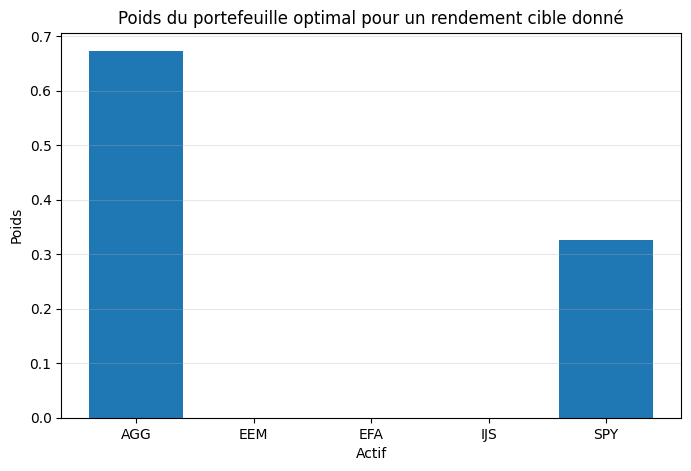

In [14]:
# 13. Visualisation des poids optimaux

weights_test = result_test["weights"]

plt.figure(figsize=(8, 5))
plt.bar(weights_test.index, weights_test.values)
plt.title("Poids du portefeuille optimal pour un rendement cible donné")
plt.xlabel("Actif")
plt.ylabel("Poids")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Interprétation du premier résultat

Nous avons ici obtenu un premier portefeuille optimal sous contrainte de rendement cible.

L’idée est simple :

- si le rendement cible est relativement faible, le solveur peut privilégier davantage les actifs défensifs ;
- si le rendement cible augmente, il devra progressivement allouer plus de poids aux actifs offrant un rendement moyen plus élevé ;
- cela se fera généralement au prix d’une augmentation de la CVaR.

Ce premier test permet donc de vérifier que notre fonction fonctionne correctement avant de construire toute la frontière efficiente.

In [15]:
# 14. Vérification rapide

print("Somme des poids :", round(result_test["weights"].sum(), 6))
print("Rendement reconstitué :", round((result_test["weights"] * mu).sum(), 6))

Somme des poids : 1.0
Rendement reconstitué : 0.005


# Construction de la frontière efficiente mean-CVaR

Nous avons testé un seul rendement cible.  
Mais un investisseur ne s'intéresse pas à un unique portefeuille : il veut comprendre comment le portefeuille optimal évolue selon le niveau de rendement recherché.

L’idée est donc de répéter l’optimisation pour plusieurs valeurs du rendement cible.

Pour chaque rendement cible, nous obtenons :

- un portefeuille optimal ;
- son rendement espéré ;
- sa CVaR minimale.

En réunissant tous ces points, nous pouvons tracer la **frontière efficiente mean-CVaR**.

## Interprétation

Chaque point de cette frontière représente le meilleur portefeuille possible pour un niveau de rendement donné, lorsque le risque est mesuré par la CVaR.

Cette courbe permet de visualiser le compromis fondamental entre :

- **performance espérée** ;
- **risque extrême**.

In [16]:
# 15. Construction de la frontière efficiente mean-CVaR

target_returns = np.linspace(mu.min(), mu.max(), 25)

frontier_results = []

for target in target_returns:
    result = optimize_portfolio_cvar(
        mu=mu,
        scenarios=scenarios,
        target_return=target,
        alpha=0.95
    )
    
    frontier_results.append({
        "target_return": target,
        "expected_return": result["expected_return"],
        "VaR": result["VaR"],
        "CVaR": result["CVaR"],
        "status": result["status"],
        **result["weights"].to_dict()
    })

frontier_df = pd.DataFrame(frontier_results)

print("Aperçu des résultats de la frontière :")
display(frontier_df.head())

Aperçu des résultats de la frontière :


,target_return,expected_return,VaR,CVaR,status,AGG,EEM,EFA,IJS,SPY
0,0.0025,0.0032,0.0110,0.0133,Optimal,0.9081,0.0000,0.0000,0.0919,0.0000
1,0.0028,0.0032,0.0110,0.0133,Optimal,0.9081,0.0000,0.0000,0.0919,0.0000
2,0.0031,0.0032,0.0110,0.0133,Optimal,0.9081,0.0000,0.0000,0.0919,0.0000
3,0.0035,0.0035,0.0108,0.0136,Optimal,0.8745,0.0000,0.0000,0.0728,0.0528
4,0.0038,0.0038,0.0121,0.0143,Optimal,0.8320,0.0000,0.0000,0.0328,0.1352


In [17]:
# 16. Vérification des solutions obtenues

print(frontier_df["status"].value_counts())

status
Optimal    25
Name: count, dtype: int64


## Lecture des résultats obtenus

Le tableau construit contient, pour chaque rendement cible :

- le rendement cible demandé ;
- le rendement effectivement obtenu ;
- la VaR ;
- la CVaR ;
- les poids de chaque actif dans le portefeuille optimal.

Cette structure est très pratique, car elle va nous permettre :

- de tracer la frontière efficiente ;
- d’étudier l’évolution des allocations ;
- d’identifier les portefeuilles les plus intéressants.

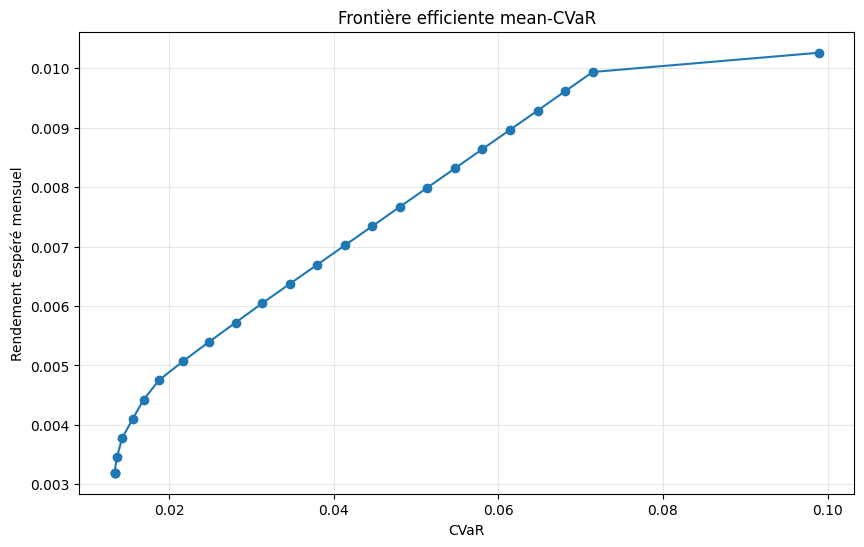

In [18]:
# 17. Graphique de la frontière efficiente mean-CVaR

plt.figure(figsize=(10, 6))
plt.plot(frontier_df["CVaR"], frontier_df["expected_return"], marker="o")
plt.title("Frontière efficiente mean-CVaR")
plt.xlabel("CVaR")
plt.ylabel("Rendement espéré mensuel")
plt.grid(alpha=0.3)
plt.show()

## Interprétation de la frontière efficiente

Ce graphique représente la relation entre :

- le **risque extrême**, mesuré par la CVaR ;
- le **rendement espéré** du portefeuille.

On doit normalement observer une courbe croissante :

- plus on demande un rendement élevé ;
- plus il faut accepter un niveau de CVaR important.

Autrement dit, il n’existe pas de rendement élevé sans prise de risque supplémentaire, en particulier lorsqu’on mesure ce risque dans les scénarios les plus défavorables.

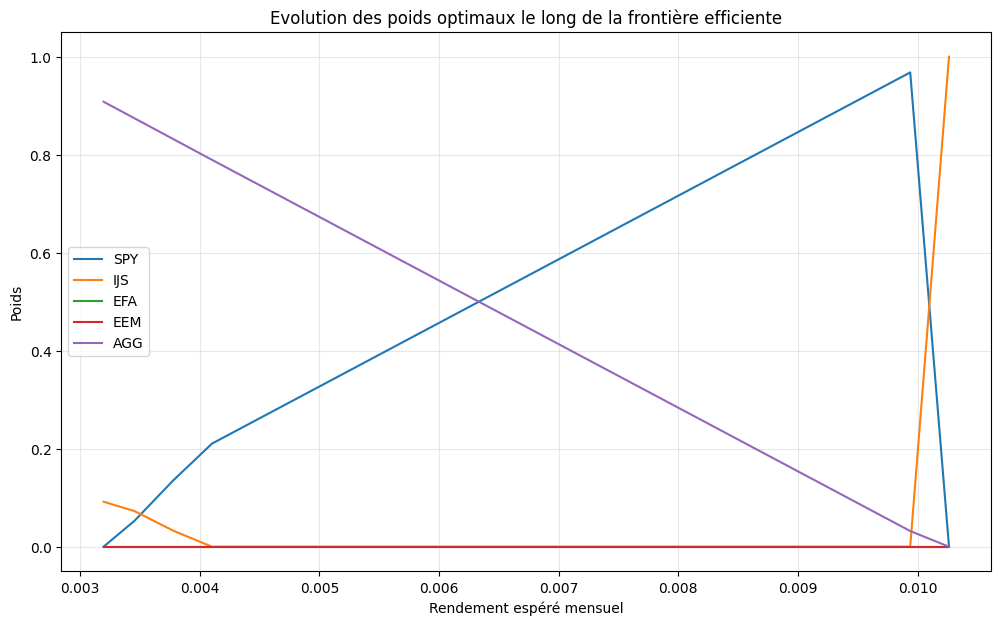

In [19]:
# 18. Evolution des poids selon le rendement cible

weights_columns = tickers

plt.figure(figsize=(12, 7))

for col in weights_columns:
    plt.plot(frontier_df["expected_return"], frontier_df[col], label=col)

plt.title("Evolution des poids optimaux le long de la frontière efficiente")
plt.xlabel("Rendement espéré mensuel")
plt.ylabel("Poids")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Lecture de l’évolution des poids

Ce graphique est très important, car il montre comment la composition du portefeuille change quand l’investisseur demande davantage de rendement.

On peut généralement observer que :

- les portefeuilles les plus prudents sont davantage investis dans les actifs défensifs ;
- lorsque le rendement cible augmente, les actifs plus dynamiques prennent progressivement plus de place ;
- certains actifs n’apparaissent que sur certaines zones de la frontière, lorsqu’ils deviennent utiles en termes de compromis rendement / risque.

Cette lecture est souvent plus riche que la frontière elle-même, car elle montre la mécanique interne de la diversification.

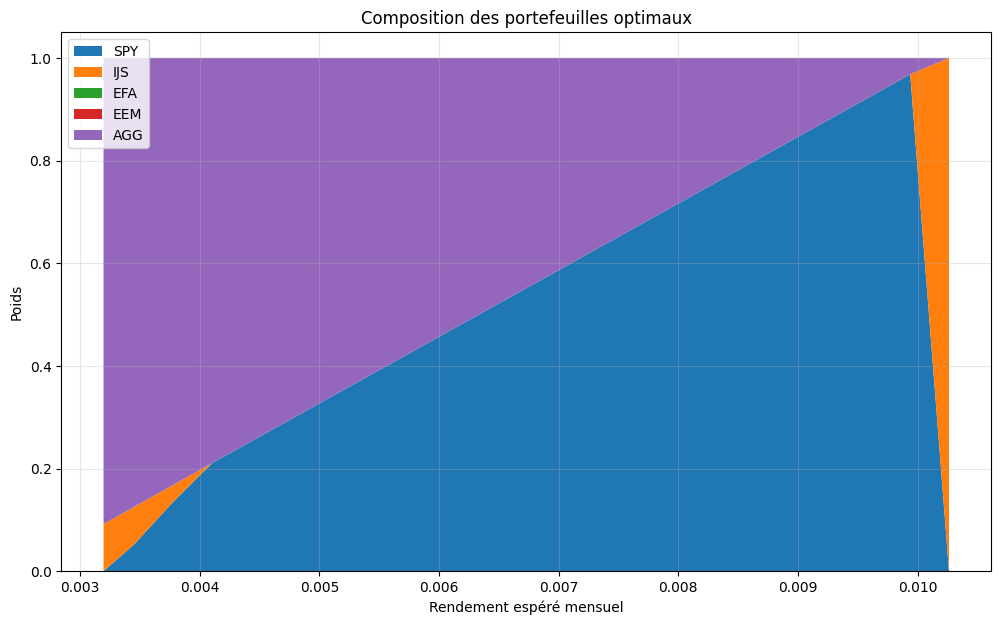

In [20]:
# 19. Aire empilée des poids

weights_only = frontier_df[weights_columns]

plt.figure(figsize=(12, 7))
plt.stackplot(
    frontier_df["expected_return"],
    [weights_only[col] for col in weights_columns],
    labels=weights_columns
)

plt.title("Composition des portefeuilles optimaux")
plt.xlabel("Rendement espéré mensuel")
plt.ylabel("Poids")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

## Ce qu’il faut observer maintenant

À ce stade, il faut regarder trois choses :

### 1. La forme de la frontière

Elle doit être globalement croissante : un rendement plus élevé exige une CVaR plus élevée.

### 2. La composition des portefeuilles prudents

Les premières zones de la frontière doivent favoriser les actifs les plus défensifs, ou ceux qui améliorent le mieux la diversification.

### 3. La montée progressive des actifs risqués

Quand on pousse le rendement cible vers le haut, les actifs offrant les rendements moyens les plus élevés doivent prendre davantage de poids.

In [21]:
# 20. Portefeuille le plus prudent et portefeuille le plus ambitieux

min_risk_portfolio = frontier_df.loc[frontier_df["CVaR"].idxmin()]
max_return_portfolio = frontier_df.loc[frontier_df["expected_return"].idxmax()]

print("Portefeuille de CVaR minimale :")
display(min_risk_portfolio.to_frame(name="Valeur"))

print("Portefeuille de rendement maximal :")
display(max_return_portfolio.to_frame(name="Valeur"))

Portefeuille de CVaR minimale :


,Valeur
target_return,0.0025
expected_return,0.0032
VaR,0.0110
CVaR,0.0133
status,Optimal
AGG,0.9081
EEM,0.0000
EFA,0.0000
IJS,0.0919
SPY,0.0000


Portefeuille de rendement maximal :


,Valeur
target_return,0.0103
expected_return,0.0103
VaR,0.0798
CVaR,0.0990
status,Optimal
AGG,0.0000
EEM,0.0000
EFA,0.0000
IJS,1.0000
SPY,0.0000


# Recherche du portefeuille au meilleur compromis rendement / CVaR

La frontière efficiente nous donne une famille de portefeuilles optimaux.  
Mais il est souvent utile d’identifier un portefeuille particulier qui offre le meilleur compromis entre rendement et risque.

Dans le cadre classique moyenne-variance, on utilise souvent le **ratio de Sharpe**.

Ici, comme le risque est mesuré par la CVaR, nous allons utiliser un ratio analogue :

$$
\text{Ratio} = \frac{\mathbb{E}[R_p]}{CVaR_\alpha}
$$

Ce ratio mesure la quantité de rendement espéré obtenue pour une unité de risque extrême.

Plus ce ratio est élevé, plus le portefeuille est intéressant du point de vue du compromis rendement / risque de queue.

In [22]:
# 21. Calcul du ratio rendement / CVaR

frontier_df["return_to_cvar"] = frontier_df["expected_return"] / frontier_df["CVaR"]

best_ratio_idx = frontier_df["return_to_cvar"].idxmax()
best_ratio_portfolio = frontier_df.loc[best_ratio_idx]

print("Portefeuille au meilleur ratio rendement / CVaR :")
display(best_ratio_portfolio.to_frame(name="Valeur"))

Portefeuille au meilleur ratio rendement / CVaR :


,Valeur
target_return,0.0038
expected_return,0.0038
VaR,0.0121
CVaR,0.0143
status,Optimal
AGG,0.8320
EEM,0.0000
EFA,0.0000
IJS,0.0328
SPY,0.1352


Poids du portefeuille sélectionné :


,Poids
SPY,0.1352
IJS,0.0328
EFA,0.0000
EEM,0.0000
AGG,0.8320


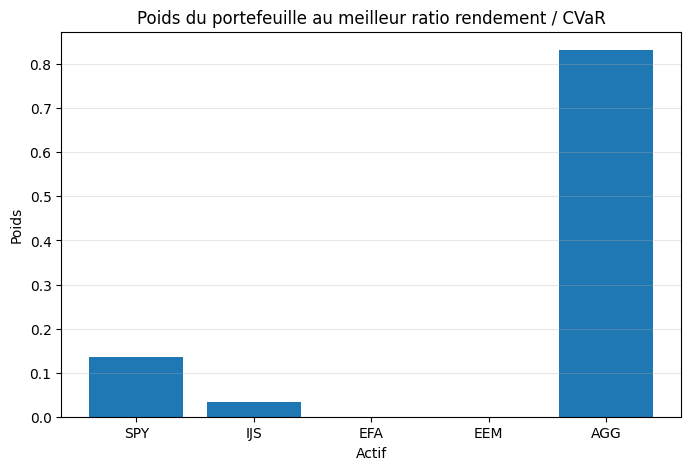

In [23]:
# 22. Poids du portefeuille au meilleur ratio

best_weights = best_ratio_portfolio[tickers]

print("Poids du portefeuille sélectionné :")
display(best_weights.to_frame(name="Poids"))

plt.figure(figsize=(8, 5))
plt.bar(best_weights.index, best_weights.values)
plt.title("Poids du portefeuille au meilleur ratio rendement / CVaR")
plt.xlabel("Actif")
plt.ylabel("Poids")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Interprétation du portefeuille au meilleur ratio

Ce portefeuille ne correspond ni au plus prudent, ni au plus agressif.

Il correspond au portefeuille qui offre, parmi tous ceux de la frontière, le meilleur rendement espéré par unité de risque extrême.

Autrement dit, il représente souvent un compromis attractif pour un investisseur qui ne cherche ni la sécurité maximale, ni la performance maximale à tout prix, mais un équilibre entre les deux.

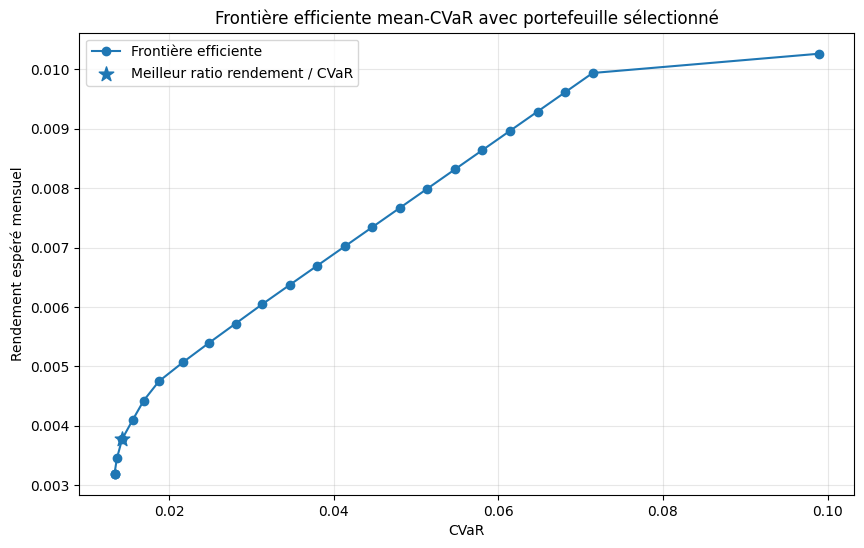

In [ ]:
# 23. Mise en évidence du meilleur portefeuille sur la frontière

plt.figure(figsize=(10, 6))
plt.plot(frontier_df["CVaR"], frontier_df["expected_return"], marker="o", label="Frontière efficiente")
plt.scatter(
    best_ratio_portfolio["CVaR"],
    best_ratio_portfolio["expected_return"],
    s=120,
    marker="*",
    label="Meilleur ratio rendement / CVaR"
)

plt.title("Frontière efficiente mean-CVaR avec portefeuille sélectionné")
plt.xlabel("CVaR")
plt.ylabel("Rendement espéré mensuel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Lecture du point mis en évidence

L’étoile correspond au portefeuille ayant le meilleur ratio rendement / CVaR parmi les portefeuilles testés.

Sa position sur la frontière est importante :

- s’il est très à gauche, cela signifie qu’un portefeuille prudent offre déjà un bon compromis ;
- s’il est plus central, cela signifie qu’un portefeuille équilibré est préférable ;
- s’il est très à droite, cela signifie que les portefeuilles plus offensifs sont davantage récompensés en rendement.

Cette lecture permet de donner une interprétation économique plus fine que la simple observation de la frontière globale.

In [25]:
# 24. Tableau récapitulatif de quelques portefeuilles importants

summary_portfolios = pd.DataFrame({
    "Portefeuille de CVaR minimale": frontier_df.loc[frontier_df["CVaR"].idxmin()],
    "Portefeuille meilleur ratio": best_ratio_portfolio,
    "Portefeuille de rendement maximal": frontier_df.loc[frontier_df["expected_return"].idxmax()]
}).T

display(summary_portfolios[["expected_return", "VaR", "CVaR", "return_to_cvar"] + tickers])

,expected_return,VaR,CVaR,return_to_cvar,SPY,IJS,EFA,EEM,AGG
Portefeuille de CVaR minimale,0.0032,0.0110,0.0133,0.2396,0.0000,0.0919,0.0000,0.0000,0.9081
Portefeuille meilleur ratio,0.0038,0.0121,0.0143,0.2649,0.1352,0.0328,0.0000,0.0000,0.8320
Portefeuille de rendement maximal,0.0103,0.0798,0.0990,0.1037,0.0000,1.0000,0.0000,0.0000,0.0000


# Bilan intermédiaire

À ce stade, nous avons :

- téléchargé les données historiques ;
- construit les rendements mensuels ;
- formulé une optimisation de portefeuille basée sur la CVaR ;
- tracé la frontière efficiente mean-CVaR ;
- identifié un portefeuille offrant un compromis attractif entre rendement espéré et risque extrême.

Les résultats obtenus montrent clairement que la composition optimale du portefeuille évolue fortement selon l’objectif de rendement :

- les allocations prudentes favorisent l’actif obligataire ;
- les allocations intermédiaires combinent obligations et actions américaines ;
- les allocations les plus offensives se concentrent sur les actifs historiquement les plus rémunérateurs.

Cela illustre bien l’intérêt d’une approche par la CVaR : au lieu de mesurer le risque par la dispersion globale des rendements, on se concentre explicitement sur les scénarios les plus défavorables.

# Comparaison des portefeuilles clés

Nous avons identifié trois portefeuilles particulièrement importants :

- le portefeuille de **CVaR minimale** ;
- le portefeuille au **meilleur ratio rendement / CVaR** ;
- le portefeuille de **rendement maximal**.

Il est maintenant utile de les comparer plus directement, à la fois :

- en termes de composition ;
- en termes de rendement espéré et de risque ;
- en termes de performance cumulée historique.

Cette étape permet de donner une lecture plus concrète des résultats obtenus.

In [29]:
# 25. Extraction des trois portefeuilles clés

min_cvar_portfolio = frontier_df.loc[frontier_df["CVaR"].idxmin()]
max_return_portfolio = frontier_df.loc[frontier_df["expected_return"].idxmax()]
best_ratio_portfolio = frontier_df.loc[frontier_df["return_to_cvar"].idxmax()]

portfolios_df = pd.DataFrame({
    "CVaR minimale": min_cvar_portfolio[tickers],
    "Meilleur ratio": best_ratio_portfolio[tickers],
    "Rendement maximal": max_return_portfolio[tickers]
}).T

display(portfolios_df)

,SPY,IJS,EFA,EEM,AGG
CVaR minimale,0.0000,0.0919,0.0000,0.0000,0.9081
Meilleur ratio,0.1352,0.0328,0.0000,0.0000,0.8320
Rendement maximal,0.0000,1.0000,0.0000,0.0000,0.0000


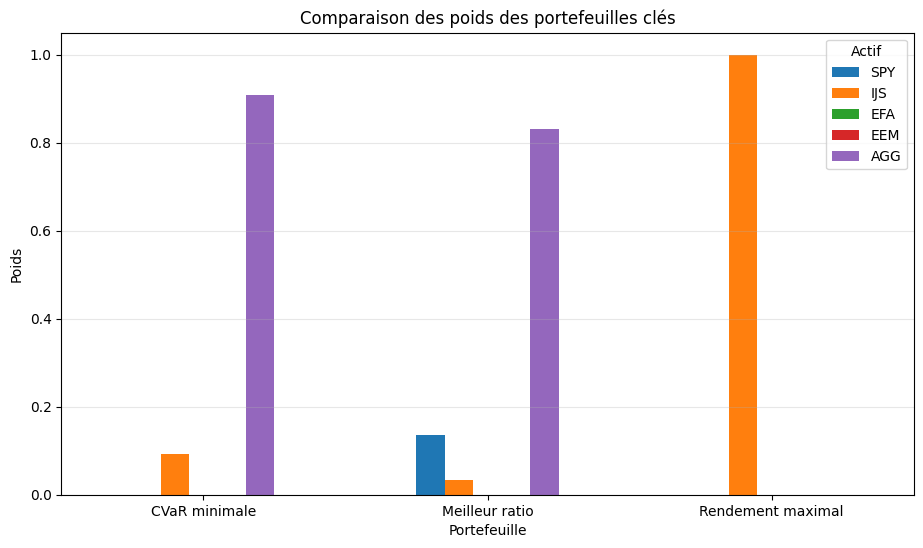

In [30]:
# 26. Comparaison des poids des trois portefeuilles

portfolios_df.plot(kind="bar", figsize=(11, 6))
plt.title("Comparaison des poids des portefeuilles clés")
plt.xlabel("Portefeuille")
plt.ylabel("Poids")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Actif")
plt.show()

## Lecture économique des compositions

Ce graphique permet de comparer immédiatement la structure des trois portefeuilles.

On retrouve une hiérarchie intuitive :

- le portefeuille de **CVaR minimale** est dominé par l’actif obligataire ;
- le portefeuille au **meilleur ratio rendement / CVaR** reste défensif, mais introduit une part plus importante d’actions ;
- le portefeuille de **rendement maximal** se concentre entièrement sur l’actif ayant offert le rendement moyen le plus élevé sur l’échantillon.

Cette comparaison illustre bien le compromis entre prudence, équilibre et recherche de performance.

In [31]:
# 27. Tableau synthétique des métriques

comparison_metrics = pd.DataFrame({
    "CVaR minimale": [
        min_cvar_portfolio["expected_return"],
        min_cvar_portfolio["VaR"],
        min_cvar_portfolio["CVaR"],
        min_cvar_portfolio["return_to_cvar"]
    ],
    "Meilleur ratio": [
        best_ratio_portfolio["expected_return"],
        best_ratio_portfolio["VaR"],
        best_ratio_portfolio["CVaR"],
        best_ratio_portfolio["return_to_cvar"]
    ],
    "Rendement maximal": [
        max_return_portfolio["expected_return"],
        max_return_portfolio["VaR"],
        max_return_portfolio["CVaR"],
        max_return_portfolio["return_to_cvar"]
    ]
}, index=["Rendement espéré", "VaR", "CVaR", "Rendement / CVaR"])

display(comparison_metrics)

,CVaR minimale,Meilleur ratio,Rendement maximal
Rendement espéré,0.0032,0.0038,0.0103
VaR,0.0110,0.0121,0.0798
CVaR,0.0133,0.0143,0.0990
Rendement / CVaR,0.2396,0.2649,0.1037


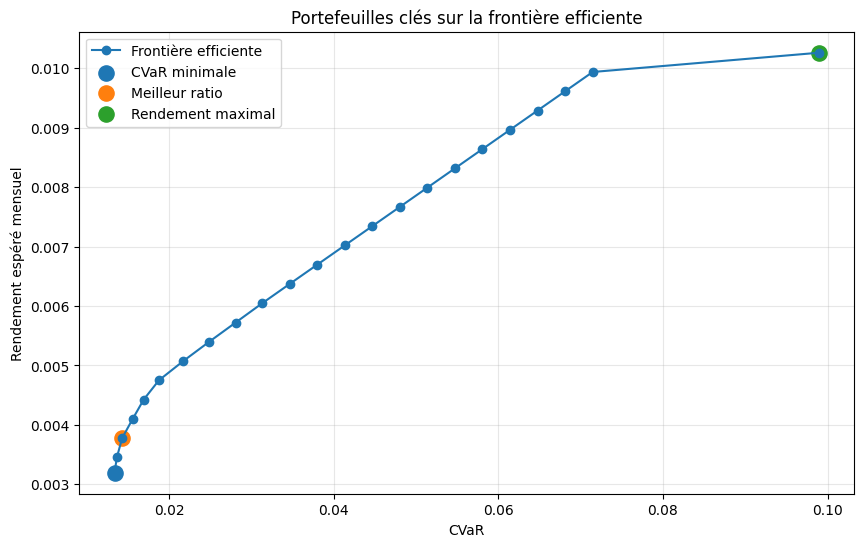

In [32]:
# 28. Position des trois portefeuilles dans le plan rendement - CVaR

plt.figure(figsize=(10, 6))

plt.plot(frontier_df["CVaR"], frontier_df["expected_return"], marker="o", label="Frontière efficiente")

plt.scatter(min_cvar_portfolio["CVaR"], min_cvar_portfolio["expected_return"], s=120, label="CVaR minimale")
plt.scatter(best_ratio_portfolio["CVaR"], best_ratio_portfolio["expected_return"], s=120, label="Meilleur ratio")
plt.scatter(max_return_portfolio["CVaR"], max_return_portfolio["expected_return"], s=120, label="Rendement maximal")

plt.title("Portefeuilles clés sur la frontière efficiente")
plt.xlabel("CVaR")
plt.ylabel("Rendement espéré mensuel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Comparaison historique de la performance des portefeuilles

Jusqu’ici, nous avons comparé les portefeuilles à partir de leurs caractéristiques statistiques.

Nous allons maintenant regarder leur comportement historique sur l’échantillon, en reconstruisant la valeur d’un investissement initial de **100 dollars** dans chacun d’eux.

Cette étape ne remplace pas l’analyse du risque, mais elle permet de rendre les résultats plus concrets et plus visuels.

In [33]:
# 29. Rendements mensuels historiques des portefeuilles clés

portfolio_returns = pd.DataFrame({
    "CVaR minimale": monthly_returns @ min_cvar_portfolio[tickers],
    "Meilleur ratio": monthly_returns @ best_ratio_portfolio[tickers],
    "Rendement maximal": monthly_returns @ max_return_portfolio[tickers]
})

display(portfolio_returns.head())

,CVaR minimale,Meilleur ratio,Rendement maximal
Date,,,
2010-02-28,0.0062,0.0074,0.0476
2010-03-31,0.0071,0.0107,0.0780
2010-04-30,0.0149,0.0124,0.0663
2010-05-31,0.0020,-0.0045,-0.0854
2010-06-30,0.0085,0.0050,-0.0828


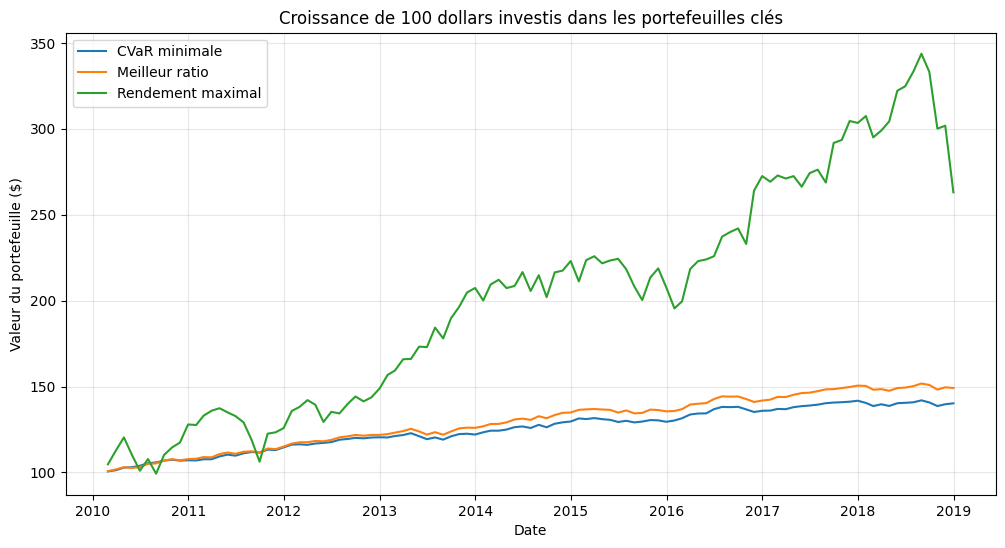

In [34]:
# 30. Croissance de 100 dollars investis

portfolio_growth = (1 + portfolio_returns).cumprod() * 100

plt.figure(figsize=(12, 6))

for col in portfolio_growth.columns:
    plt.plot(portfolio_growth.index, portfolio_growth[col], label=col)

plt.title("Croissance de 100 dollars investis dans les portefeuilles clés")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

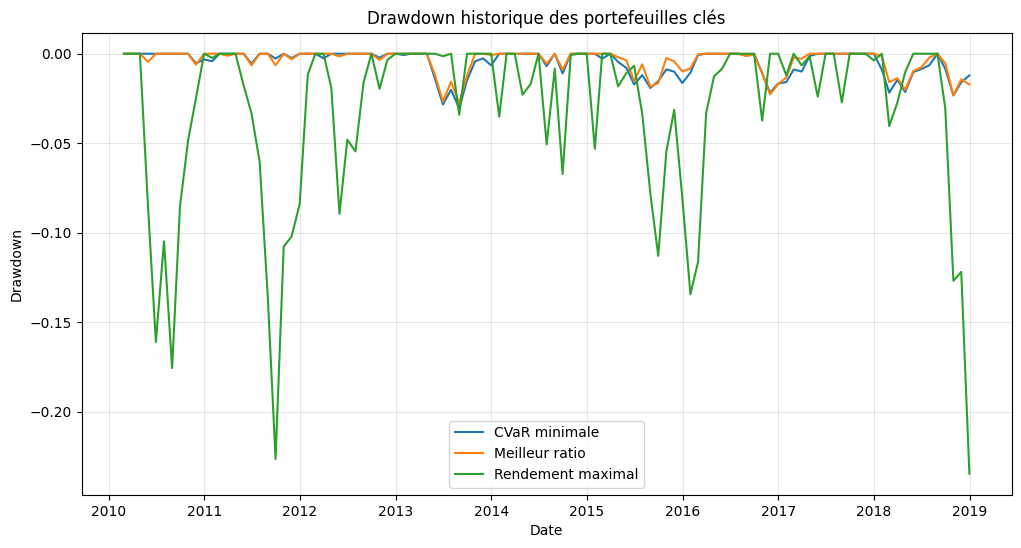

In [35]:
# 31. Drawdown historique des portefeuilles clés

portfolio_drawdown = portfolio_growth / portfolio_growth.cummax() - 1

plt.figure(figsize=(12, 6))

for col in portfolio_drawdown.columns:
    plt.plot(portfolio_drawdown.index, portfolio_drawdown[col], label=col)

plt.title("Drawdown historique des portefeuilles clés")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Pourquoi regarder le drawdown ?

Le drawdown mesure la perte subie par rapport au plus haut atteint jusque-là.

Il est très utile pour compléter la lecture de la CVaR, car il donne une vision plus intuitive des périodes de baisse.

Un portefeuille peut avoir un bon rendement moyen, mais subir des phases de recul importantes.  
Comparer les drawdowns permet donc d’évaluer plus concrètement la robustesse des portefeuilles construits.

In [36]:
# 32. Statistiques historiques complémentaires

historical_stats = pd.DataFrame(index=portfolio_returns.columns)

historical_stats["Rendement mensuel moyen"] = portfolio_returns.mean()
historical_stats["Volatilité mensuelle"] = portfolio_returns.std()
historical_stats["Rendement cumulé final"] = portfolio_growth.iloc[-1] / 100 - 1
historical_stats["Drawdown minimal"] = portfolio_drawdown.min()

display(historical_stats)

,Rendement mensuel moyen,Volatilité mensuelle,Rendement cumulé final,Drawdown minimal
CVaR minimale,0.0032,0.0076,0.4024,-0.0306
Meilleur ratio,0.0038,0.0082,0.4915,-0.0275
Rendement maximal,0.0103,0.0489,1.6307,-0.2347


## Bilan des comparaisons

Ces derniers graphiques permettent de relier l’optimisation théorique à une lecture plus concrète des portefeuilles.

On observe généralement que :

- le portefeuille de **CVaR minimale** est le plus défensif ;
- le portefeuille au **meilleur ratio rendement / CVaR** constitue souvent un compromis équilibré ;
- le portefeuille de **rendement maximal** est aussi le plus exposé aux fluctuations défavorables.

Cela confirme l’idée centrale du projet : chercher uniquement le rendement conduit souvent à des portefeuilles très concentrés, alors qu’une approche fondée sur la CVaR permet de mieux contrôler le risque dans les scénarios extrêmes.

# Analyse finale des résultats

Les résultats obtenus mettent bien en évidence le compromis fondamental entre rendement et risque extrême.

## 1. Portefeuille de CVaR minimale

Le portefeuille de risque minimal est très majoritairement investi en obligations via $AGG$, avec une faible exposition à $IJS$.

Cela est cohérent avec l’objectif poursuivi : minimiser l’exposition aux scénarios les plus défavorables.  
Le rendement espéré est plus faible, mais la stabilité du portefeuille est plus importante.

## 2. Portefeuille au meilleur ratio rendement / CVaR

Le portefeuille au meilleur ratio conserve une structure défensive, mais ajoute une part d’actions américaines à travers $SPY$ et une petite exposition à $IJS$.

Il constitue un compromis intéressant :

- il améliore le rendement espéré ;
- tout en gardant une CVaR relativement faible ;
- et son drawdown historique reste contenu.

## 3. Portefeuille de rendement maximal

Le portefeuille de rendement maximal est entièrement concentré sur $IJS$.

Cette solution maximise le rendement moyen observé sur l’échantillon, mais elle s’accompagne également :

- d’une VaR nettement plus élevée ;
- d’une CVaR beaucoup plus importante ;
- et d’un drawdown historique nettement plus sévère.

## 4. Enseignement principal

L’approche mean-CVaR montre qu’un portefeuille optimal ne dépend pas uniquement du rendement visé, mais aussi de la manière dont on choisit de mesurer le risque.

En remplaçant la variance par la CVaR, on ne se contente plus de mesurer la dispersion générale des rendements : on se concentre explicitement sur les pertes extrêmes.

C’est précisément ce qui rend cette approche pertinente pour un investisseur soucieux de mieux contrôler le risque dans les pires scénarios.

# Limites de l’approche

Même si cette approche est très intéressante, elle présente plusieurs limites qu’il faut garder en tête.

## 1. Dépendance aux données historiques

La CVaR est ici estimée à partir de scénarios historiques mensuels.  
Autrement dit, on suppose implicitement que le passé fournit une information utile sur les risques futurs.

Cette hypothèse est utile pour construire un modèle simple, mais elle reste imparfaite.

## 2. Univers d’actifs réduit

Le projet repose sur seulement cinq ETF.  
Cela permet une lecture claire, mais cela limite la richesse des possibilités de diversification.

## 3. Portefeuilles parfois très concentrés

Sans contrainte supplémentaire, l’optimisation peut conduire à des portefeuilles très concentrés sur quelques actifs.

Cela peut être mathématiquement optimal dans le modèle, mais moins réaliste en pratique.

## 4. Absence de coûts de transaction et de contraintes opérationnelles

Nous n’avons pas pris en compte :

- les coûts de transaction ;
- les frais ;
- les contraintes de rééquilibrage ;
- les limites de poids par actif.

Dans un cadre professionnel, ces éléments devraient être intégrés.

# Pistes d’amélioration

Ce projet peut être prolongé de plusieurs façons.

## 1. Ajouter des contraintes réalistes

On pourrait imposer par exemple :

- un poids maximal par actif ;
- un poids minimal sur certaines classes d’actifs ;
- ou encore des contraintes sectorielles.

## 2. Comparer avec Markowitz

Une extension naturelle serait de comparer :

- la frontière moyenne-variance ;
- et la frontière mean-CVaR.

Cela permettrait de voir concrètement ce que change le choix de la mesure de risque.

## 3. Tester d’autres données

On pourrait élargir l’univers d’investissement à davantage d’ETF, ou utiliser des données plus récentes.

## 4. Étudier l’out-of-sample

Une autre amélioration importante serait de séparer l’échantillon en deux parties :

- une période d’estimation ;
- une période de test.

Cela permettrait d’évaluer plus rigoureusement la robustesse des portefeuilles construits.

# Conclusion générale

Ce projet a permis de reconstruire une optimisation de portefeuille fondée sur la **CVaR**.

L’intérêt principal de cette approche est de ne pas mesurer le risque uniquement par la dispersion globale des rendements, mais de s’intéresser directement aux pertes extrêmes.

Les résultats obtenus montrent clairement qu’il existe un arbitrage entre :

- la recherche de performance ;
- et le contrôle du risque de queue.

Le portefeuille de CVaR minimale privilégie la robustesse, le portefeuille de rendement maximal privilégie la performance, tandis que le portefeuille au meilleur ratio rendement / CVaR fournit un compromis plus équilibré.

Cette méthode constitue donc une alternative intéressante à l’approche moyenne-variance classique pour construire des portefeuilles plus sensibles au risque extrême.